# 2. Classification with CIFAR-10

Universidad de Zaragoza

Names: Jorge Ruiz González & Hugo López Sola

NIAs: 826685, 875455

This is the notebook to train classification models and evaluate the performance of the models using the CIFAR-10 Dataset
https://www.cs.toronto.edu/~kriz/cifar.html

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn import preprocessing
from keras.datasets import cifar10
import cv2

In [5]:
# This class implements the extraction of a GIST descriptor from an image.
# The GIST descriptor was originally proposed in https://people.csail.mit.edu/torralba/code/spatialenvelope/
# This code was taken from https://github.com/imoken1122/GIST-feature-extractor, on september 2020

import numpy as np
import numpy.matlib as nm
import numpy.fft as f
from PIL import Image

class GIST():
    def __init__(self,param):
        self.param = param

    def _createGabor(self,orr,n):

        gabor_param = []
        Nscalse = len(orr)
        Nfilters = sum(orr)
        if len(n) == 1:
            n = [n[0],n[0]]
        for i in range(Nscalse):
            for j in range(orr[i]):
                gabor_param.append([.35,.3/(1.85**(i)),16*orr[i]**2/32**2, np.pi/(orr[i])*(j)])
        gabor_param = np.array(gabor_param)
        fx, fy = np.meshgrid(np.arange(-n[1]/2,n[1]/2-1 + 1), np.arange(-n[0]/2, n[0]/2-1 + 1))
        fr = f.fftshift(np.sqrt(fx**2+fy**2))
        t = f.fftshift(np.angle(fx+ 1j*fy))

        G = np.zeros([n[0],n[1],Nfilters])
        for i in range(Nfilters):
            tr = t + gabor_param[i,3]
            tr+= 2*np.pi*(tr < -np.pi) - 2 * np.pi*(tr>np.pi)
            G[:,:,i] = np.exp(-10*gabor_param[i,0]*(fr/n[1]/gabor_param[i,1]-1)**2-2*gabor_param[i,2]*np.pi*tr**2)

        return G

    def _more_config(self,img):

        self.param["imageSize"] = [img.shape[0], img.shape[1]]
        self.param["G"] = self._createGabor(self.param["orientationsPerScale"],np.array(self.param["imageSize"])+2*self.param["boundaryExtension"])


    def _preprocess(self,img):
        M = self.param["imageSize"]
        if len(M) == 1:
            M = [M, M]
        scale = np.max([M[0]/img.shape[0], M[1]/img.shape[1]])
        newsize = list(map(int,np.round(np.array([img.shape[1],img.shape[0]]) * scale)))
        img = np.array(Image.fromarray(img).resize(newsize, Image.BILINEAR))
        #img = imresize(img,newsize,'bilinear')

        nr,nc = img.shape
        sr = (nr-M[0])/2
        sc = (nc-M[1])/2

        img = img[int(sr):int(sr+M[0])+ 1,int(sc):int(sc+M[1])+1]
        img = img- np.min(img)
        if np.sum(img) != 0:
            img = 255*(img/np.max(img))

        return img


    def _prefilt(self,img):

        w = 5
        fc=self.param["fc_prefilt"]
        s1 = fc/np.sqrt(np.log(2))
        img=np.log(img +1 )
        img = np.pad(img,[w,w],"symmetric")

        sn,sm = img.shape
        n = np.max([sn,sm])
        n += n%2

        if sn == sm:
            img = np.pad(img,[0,int(n-sn)],"symmetric")
        else:
            img = np.pad(img,[0,int(n-sn)], "symmetric")[:,:sm]

        fx,fy = np.meshgrid(np.arange(-n/2,n/2-1 + 1),np.arange(-n/2,n/2-1 + 1))
        gf = f.fftshift((np.exp(-(fx**2+fy**2)/(s1**2))))
        gf = nm.repmat(gf,1,1)
        output = img - np.real(f.ifft2(f.fft2(img)*gf))

        localstd = nm.repmat(np.sqrt(abs(f.ifft2(f.fft2(output**2)*gf))), 1 ,1 )
        output = output/(0.2+localstd)
        output = output[w:sn-w, w:sm-w]
        return output

    def _gistGabor(self,img):

        w = self.param["numberBlocks"]
        G = self.param["G"]
        be = self.param["boundaryExtension"]
        ny,nx,Nfilters = G.shape
        W = w[0] * w[1]
        N = 1
        g = np.zeros((W*Nfilters, N))
        img = np.pad(img,[be,be],"symmetric")
        img = f.fft2(img)

        k = 0
        for n in range(Nfilters):
            ig = abs(f.ifft2(img*nm.repmat(G[:,:,n],1,1)))
            ig = ig[be:ny-be,be:nx-be]
            v = self._downN(ig,w)
            g[k:k+W,0] = v.reshape([W,N],order = "F").flatten()
            k += W
        return np.array(g)

    def _downN(self,x,N):
        nx = list(map(int,np.floor(np.linspace(0,x.shape[0],N[0]+1))))
        ny = list(map(int,np.floor(np.linspace(0,x.shape[1],N[1]+1))))
        y  = np.zeros((N[0],N[1]))
        for xx in range(N[0]):
            for yy in range(N[1]):
                a = x[nx[xx]:nx[xx+1], ny[yy]:ny[yy+1]]
                v = np.mean(np.mean(a,0))
                y[xx,yy]=v
        return y

    def _gist_extract(self,img):

        self._more_config(img)

        img = self._preprocess(img)

        output = self._prefilt(img)

        gist = self._gistGabor(output)

        return gist.flatten()

In [ ]:
# get training data
(im_train_and_val, y_train_and_val), (im_test, y_test) = cifar10.load_data()
print('Training set size: {}'.format(im_train_and_val.shape))

# Parameters needed for the GIST descriptor
param = {
        "orientationsPerScale":np.array([8,8]),
         "numberBlocks":[4,4],
        "fc_prefilt":10,
        "boundaryExtension":32
}

# Extract the GIST descriptor of image 134
mygist = GIST(param)
imggray = cv2.cvtColor(im_train_and_val[134,:,:,:], cv2.COLOR_RGB2GRAY)
plt.imshow(im_train_and_val[134,:,:,:])
plt.show()
gistdesc = np.squeeze(mygist._gist_extract(imggray))
print('GIST descriptor: {}'.format(gistdesc.shape))

In [ ]:
# Parameters needed for the GIST descriptor
param = {
        "orientationsPerScale":np.array([8,8]),
         "numberBlocks":[4,4],
        "fc_prefilt":10,
        "boundaryExtension":32
}

# Extract GIST descriptor of every image in the dataset
mygist = GIST(param)

n_train_and_val = im_train_and_val.shape[0]
n_test = im_test.shape[0]
x_train_and_val_gist = np.zeros((n_train_and_val,256))
x_test_gist = np.zeros((n_test,256))

for i in range(n_train_and_val):
  imggray = cv2.cvtColor(im_train_and_val[i,:,:,:], cv2.COLOR_RGB2GRAY)
  x_train_and_val_gist[i,:] = np.squeeze(mygist._gist_extract(imggray))
  if (i + 1) % 1000 == 0 or i + 1 == n_train_and_val:
    print(f'Converted {i + 1}/{n_train_and_val} training images')

for i in range(n_test):
  imggray = cv2.cvtColor(im_test[i,:,:,:], cv2.COLOR_RGB2GRAY)
  x_test_gist[i,:] = np.squeeze(mygist._gist_extract(imggray))
  if (i + 1) % 1000 == 0 or i + 1 == n_test:
    print(f'Converted {i + 1}/{n_test} test images')

## 2.1 Split the data, explore it and train several promising models
The original cells above load CIFAR-10 and calculate GIST descriptors.
We use 10,000 training images and 2,000 validation images to keep training time manageable.
The official 10,000 test images are reserved for final evaluation.

Dataset: 60000 images
Image shape: (32, 32, 3)
Features per image: 3072
Training: 10000 validation: 2000 test: 10000


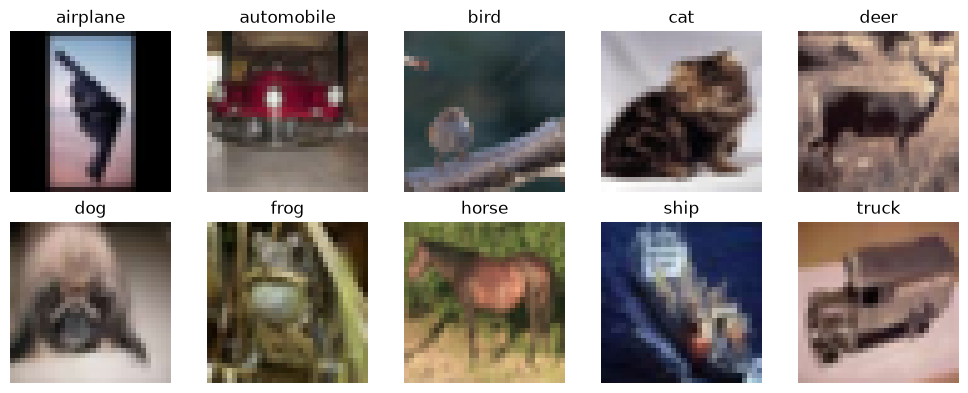

In [8]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score

y_train_and_val = y_train_and_val.ravel()
y_test = y_test.ravel()
class_names = ["airplane", "automobile", "bird", "cat", "deer",
               "dog", "frog", "horse", "ship", "truck"]

subset_idx, _ = train_test_split(
    np.arange(len(y_train_and_val)), train_size=12000,
    stratify=y_train_and_val, random_state=42)
train_idx, val_idx = train_test_split(
    subset_idx, test_size=2000, stratify=y_train_and_val[subset_idx], random_state=42)
y_train = y_train_and_val[train_idx]
y_val = y_train_and_val[val_idx]

print("Dataset:", len(im_train_and_val) + len(im_test), "images")
print("Image shape:", im_train_and_val.shape[1:])
print("Features per image:", 32 * 32 * 3)
print("Training:", len(train_idx), "validation:", len(val_idx), "test:", len(y_test))

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for label, ax in enumerate(axes.flat):
    index = train_idx[np.where(y_train == label)[0][0]]
    ax.imshow(im_train_and_val[index])
    ax.set_title(class_names[label])
    ax.axis("off")
plt.tight_layout()
plt.show()

We compare k-NN, logistic regression and SVM, as seen in the slides.
PCA reduces the pixel data to 64 components. Scaling and PCA use training data only.
We use k = 5 for k-NN and C = 1 for logistic regression. For each SVM, C and gamma are selected by 3-fold cross-validation on a stratified subset of the training set; the chosen model is then refit on all training images. Validation is used for comparison, and test is reserved for final evaluation.

In [9]:
# Prepare pixel features.
raw_train = im_train_and_val[train_idx].reshape(len(train_idx), -1) / 255.0
raw_val = im_train_and_val[val_idx].reshape(len(val_idx), -1) / 255.0

pixel_scaler = StandardScaler()
raw_train = pixel_scaler.fit_transform(raw_train)
raw_val = pixel_scaler.transform(raw_val)

pca = PCA(n_components=64, svd_solver="randomized", random_state=42)
X_raw_train = pca.fit_transform(raw_train)
X_raw_val = pca.transform(raw_val)

In [ ]:
# Train and evaluate the classifiers using pixel features.
raw_models = {
    "k-NN": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(C=1, max_iter=2000),
    "SVM": SVC(C=1, kernel="rbf")
}
rows = []

for name, model in raw_models.items():
    model.fit(X_raw_train, y_train)
    y_pred = model.predict(X_raw_val)
    accuracy = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average="macro")
    rows.append({"Model": name, "Accuracy": accuracy, "Macro F1": f1})
    print(f"{name}: validation accuracy = {100 * accuracy:.2f}%")

raw_results = pd.DataFrame(rows).set_index("Model")
print(raw_results.round(3))

In [ ]:
# Ajuste de C y gamma del SVM de pixels mediante CV solo con entrenamiento.
# Escalado y PCA se vuelven a ajustar dentro de cada fold para evitar fuga de informacion.
pixel_train_raw = im_train_and_val[train_idx].reshape(len(train_idx), -1) / 255.0
pixel_val_raw = im_train_and_val[val_idx].reshape(len(val_idx), -1) / 255.0
pixel_tune_idx, _ = train_test_split(
    np.arange(len(y_train)), train_size=min(3000, len(y_train)),
    stratify=y_train, random_state=42
)
pixel_svm_search = GridSearchCV(
    make_pipeline(
        StandardScaler(),
        PCA(n_components=64, svd_solver="randomized", random_state=42),
        SVC()
    ),
    {"svc__C": [1, 10], "svc__gamma": ["scale", 0.01]},
    cv=3, scoring="accuracy", n_jobs=1, refit=True
)
pixel_svm_search.fit(pixel_train_raw[pixel_tune_idx], y_train[pixel_tune_idx])
print("Best pixel SVM parameters:", pixel_svm_search.best_params_)
print("Best 3-fold CV accuracy (training subset):", round(pixel_svm_search.best_score_, 3))

# Refit with the selected settings using all 10,000 training images.
raw_models["SVM"] = make_pipeline(
    StandardScaler(),
    PCA(n_components=64, svd_solver="randomized", random_state=42),
    SVC(
        C=pixel_svm_search.best_params_["svc__C"],
        gamma=pixel_svm_search.best_params_["svc__gamma"]
    )
)
raw_models["SVM"].fit(pixel_train_raw, y_train)
pixel_svm_val_prediction = raw_models["SVM"].predict(pixel_val_raw)
raw_results.loc["SVM", "Accuracy"] = accuracy_score(y_val, pixel_svm_val_prediction)
raw_results.loc["SVM", "Macro F1"] = f1_score(
    y_val, pixel_svm_val_prediction, average="macro"
)
print("Pixel models after SVM tuning:")
print(raw_results.round(3))


Best pixel SVM parameters: {'svc__C': 1, 'svc__gamma': 'scale'}
Best 3-fold CV accuracy (training subset): 0.388
Pixel models after SVM tuning:
                     Accuracy  Macro F1
Model                                  
k-NN                    0.342     0.331
Logistic Regression     0.376     0.370
SVM                     0.450     0.446


## 2.2 Transform the data
We now use the GIST descriptors calculated in the original cells.
The 16 filters and 4 × 4 grid give 256 features describing texture and spatial layout.
Both representations use the same training and validation images.

In [ ]:
# Modelos GIST. Los pipelines ajustan el escalado solo con los datos de entrenamiento.
X_gist_train_raw = x_train_and_val_gist[train_idx]
X_gist_val_raw = x_train_and_val_gist[val_idx]

gist_models = {
    "k-NN": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
    "Logistic Regression": make_pipeline(
        StandardScaler(), LogisticRegression(C=1, max_iter=2000)
    ),
}

# Ajuste de C y gamma con CV en un subconjunto estratificado del entrenamiento.
# Despues se reajusta el mejor SVM con todo el entrenamiento (10.000 imagenes).
tune_idx, _ = train_test_split(
    np.arange(len(y_train)), train_size=min(5000, len(y_train)),
    stratify=y_train, random_state=42
)
svm_search = GridSearchCV(
    make_pipeline(StandardScaler(), SVC()),
    {
        "svc__C": [0.1, 1, 10],
        "svc__gamma": ["scale", 0.01, 0.1],
    },
    cv=3, scoring="accuracy", n_jobs=1, refit=True
)
svm_search.fit(X_gist_train_raw[tune_idx], y_train[tune_idx])
print("Best GIST SVM parameters:", svm_search.best_params_)
print("Best 3-fold CV accuracy (training subset):", round(svm_search.best_score_, 3))

best_svm_params = {
    "C": svm_search.best_params_["svc__C"],
    "gamma": svm_search.best_params_["svc__gamma"],
}
best_gist_svm = make_pipeline(
    StandardScaler(), SVC(**best_svm_params)
)
best_gist_svm.fit(X_gist_train_raw, y_train)
gist_models["SVM"] = best_gist_svm

rows = []
for name, model in gist_models.items():
    if name != "SVM":
        model.fit(X_gist_train_raw, y_train)
    y_pred = model.predict(X_gist_val_raw)
    accuracy = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average="macro")
    rows.append({"Model": name, "Accuracy": accuracy, "Macro F1": f1})
    print(f"{name}: validation accuracy = {100 * accuracy:.2f}%")

gist_results = pd.DataFrame(rows).set_index("Model")
print(gist_results.round(3))
best_name = gist_results["Accuracy"].idxmax()
print("Best GIST model on validation:", best_name)


Best GIST SVM parameters: {'svc__C': 10, 'svc__gamma': 'scale'}
Best 3-fold CV accuracy (training subset): 0.593
k-NN: validation accuracy = 48.90%
Logistic Regression: validation accuracy = 54.70%
SVM: validation accuracy = 62.85%
                     Accuracy  Macro F1
Model                                  
k-NN                    0.489     0.488
Logistic Regression     0.547     0.545
SVM                     0.628     0.629
Best GIST model on validation: SVM


We evaluate the fixed models on the test set. Accuracy measures the fraction of correct
predictions; macro F1 gives equal weight to each class. Comparing pixels and GIST shows
the effect of choosing different features.

In [ ]:
raw_test = im_test.reshape(len(im_test), -1) / 255.0
X_raw_test = pca.transform(pixel_scaler.transform(raw_test))
X_gist_test = x_test_gist

rows = []
for name in raw_models:
    if name == "SVM":
        raw_prediction = raw_models[name].predict(raw_test)
    else:
        raw_prediction = raw_models[name].predict(X_raw_test)
    gist_prediction = gist_models[name].predict(X_gist_test)
    rows.append({
        "Model": name,
        "Pixel accuracy": accuracy_score(y_test, raw_prediction),
        "GIST accuracy": accuracy_score(y_test, gist_prediction),
        "Pixel macro F1": f1_score(y_test, raw_prediction, average="macro"),
        "GIST macro F1": f1_score(y_test, gist_prediction, average="macro")
    })

test_results = pd.DataFrame(rows).set_index("Model")
print(test_results.round(3))
for name in test_results.index:
    gain = test_results.loc[name, "GIST accuracy"] - test_results.loc[name, "Pixel accuracy"]
    print(f"{name}: GIST changes accuracy by {100 * gain:.1f} percentage points")

prediction = gist_models[best_name].predict(X_gist_test)

                     Pixel accuracy  GIST accuracy  Pixel macro F1  GIST macro F1
Model
k-NN                          0.335          0.497           0.328         0.496
Logistic Regression           0.378          0.538           0.373         0.535
SVM                           0.465          0.625           0.462         0.625
k-NN: GIST changes accuracy by 16.2 percentage points
Logistic Regression: GIST changes accuracy by 16.0 percentage points
SVM: GIST changes accuracy by 16.0 percentage points


              precision    recall  f1-score   support

airplane      0.657     0.698     0.677      1000
automobile    0.739     0.757     0.748      1000
bird          0.496     0.492     0.494      1000
cat           0.411     0.433     0.422      1000
deer          0.572     0.559     0.566      1000
dog           0.526     0.520     0.523      1000
frog          0.678     0.692     0.685      1000
horse         0.696     0.659     0.677      1000
ship          0.719     0.713     0.716      1000
truck         0.767     0.724     0.745      1000

accuracy                          0.625     10000
macro avg     0.626     0.625     0.625     10000
weighted avg  0.626     0.625     0.625     10000


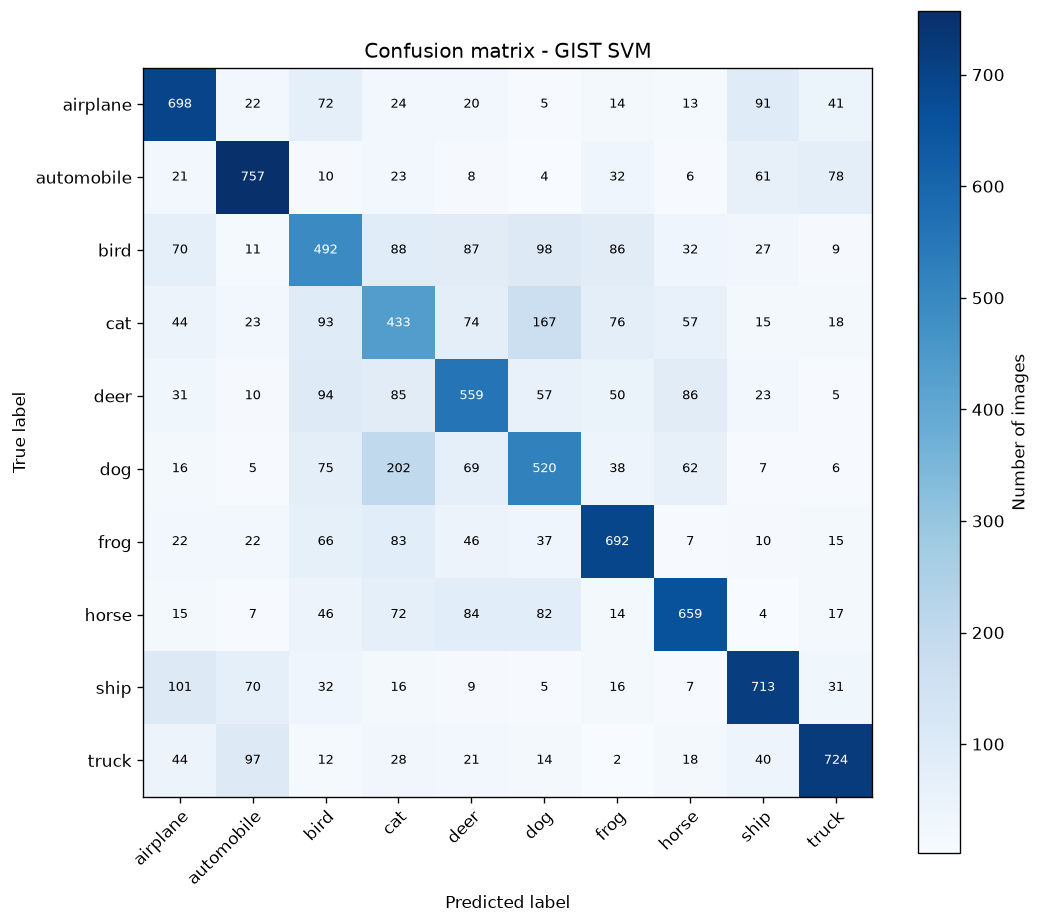

In [ ]:
# Informe por clase y matriz de confusion del modelo GIST elegido en validacion
print(classification_report(
    y_test, prediction, labels=np.arange(len(class_names)),
    target_names=class_names, digits=3, zero_division=0
))

cm = confusion_matrix(y_test, prediction, labels=np.arange(len(class_names)))
fig, ax = plt.subplots(figsize=(9, 8))
image = ax.imshow(cm, interpolation="nearest", cmap="Blues")
fig.colorbar(image, ax=ax, label="Number of images")
ax.set(
    xticks=np.arange(len(class_names)), yticks=np.arange(len(class_names)),
    xticklabels=class_names, yticklabels=class_names,
    xlabel="Predicted label", ylabel="True label",
    title=f"Confusion matrix - GIST {best_name}"
)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
threshold = cm.max() / 2
for row in range(cm.shape[0]):
    for col in range(cm.shape[1]):
        ax.text(
            col, row, str(cm[row, col]), ha="center", va="center",
            color="white" if cm[row, col] > threshold else "black", fontsize=8
        )
fig.tight_layout()
plt.show()


## 2.3 Show examples of the classification results
We show correct and incorrect predictions from the GIST model selected using validation.
Similar textures and shapes can cause errors because GIST keeps coarse structure and loses
colour and fine details.

In [ ]:
correct = np.where(prediction == y_test)[0][:6]
incorrect = np.where(prediction != y_test)[0][:6]

fig, axes = plt.subplots(2, 6, figsize=(14, 6))
for row, indices in enumerate([correct, incorrect]):
    title = "Correct" if row == 0 else "Incorrect"
    for ax in axes[row]:
        ax.axis("off")
    for ax, index in zip(axes[row], indices):
        ax.imshow(im_test[index])
        ax.set_title(f"{title}\nTrue: {class_names[y_test[index]]}\nPred: {class_names[prediction[index]]}", fontsize=9)
plt.tight_layout(h_pad=3)
plt.show()